# Pemeriksaan Awal Dataset — Kelompok 3
**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Notebook ini menjawab tugas pertemuan lalu: **cek kondisi data** sebelum masuk ke tahap
preprocessing — bentuk data, missing value, duplikat, dan kelayakannya untuk dipakai.

**Sumber data (sekunder / publik):** [Stroke Prediction Dataset — Kaggle (fedesoriano)](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset),
5.110 rekam medis pasien.


## 1. Muat Data

Diambil langsung dari URL, jadi tidak perlu upload file ke Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

URL = "https://raw.githubusercontent.com/ray-project/raydp/master/tutorials/dataset/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(URL)

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
df.head()

Jumlah baris : 5110
Jumlah kolom : 12


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Struktur dan Tipe Data

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [3]:
# Pisahkan kolom numerik dan kategorikal
numerik = df.select_dtypes(include=np.number).columns.tolist()
kategorik = df.select_dtypes(exclude=np.number).columns.tolist()

print("Kolom numerik    :", numerik)
print("Kolom kategorikal:", kategorik)

Kolom numerik    : ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Kolom kategorikal: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.83,21161.72,67.00,17741.25,36932.00,54682.00,72940.00
age,5110.0,43.23,22.61,0.08,25.00,45.00,61.00,82.00
hypertension,5110.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
heart_disease,5110.0,0.05,0.23,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5110.0,106.15,45.28,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.89,7.85,10.30,23.50,28.10,33.10,97.60
stroke,5110.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


## 3. Pemeriksaan Missing Value

Tugas dari Bapak: cek apakah ada nilai yang kosong.

In [5]:
kosong = df.isna().sum()
kosong = kosong[kosong > 0].to_frame("jumlah_kosong")
kosong["persen"] = (kosong.jumlah_kosong / len(df) * 100).round(2)
print("Kolom yang punya missing value:")
display(kosong)

if kosong.empty:
    print("Tidak ada missing value eksplisit.")

Kolom yang punya missing value:


,jumlah_kosong,persen
bmi,201,3.93


### 3a. Missing Value yang Tersembunyi

Missing value tidak selalu berbentuk `NaN`. Kadang ia menyamar sebagai kategori biasa
seperti `"Unknown"`, `"N/A"`, atau angka `0` yang mustahil. Ini harus dicek manual —
kalau terlewat, model akan menganggapnya sebagai informasi yang bermakna.

In [6]:
for kol in kategorik:
    print(f"--- {kol}")
    print(df[kol].value_counts().to_string())
    print()

--- gender
gender
Female    2994
Male      2115
Other        1

--- ever_married
ever_married
Yes    3353
No     1757

--- work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22

--- Residence_type
Residence_type
Urban    2596
Rural    2514

--- smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789



In [7]:
# Periksa nilai yang mencurigakan
mencurigakan = ["Unknown", "unknown", "N/A", "NA", "?", "-", ""]

for kol in kategorik:
    ketemu = df[kol].isin(mencurigakan).sum()
    if ketemu:
        print(f'{kol}: {ketemu} baris ({ketemu/len(df)*100:.1f}%) bernilai tersembunyi-kosong')

smoking_status: 1544 baris (30.2%) bernilai tersembunyi-kosong


## 4. Pemeriksaan Duplikat

In [8]:
print("Duplikat baris penuh      :", df.duplicated().sum())

# id seharusnya unik — kalau tidak, ada masalah pada data
if "id" in df.columns:
    print("Nilai id duplikat         :", df.id.duplicated().sum())
    print("Jumlah id unik            :", df.id.nunique(), "dari", len(df), "baris")

# Duplikat setelah kolom id dibuang (pasien berbeda tapi datanya identik)
tanpa_id = df.drop(columns=["id"], errors="ignore")
print("Duplikat tanpa kolom id   :", tanpa_id.duplicated().sum())

Duplikat baris penuh      : 0
Nilai id duplikat         : 0
Jumlah id unik            : 5110 dari 5110 baris
Duplikat tanpa kolom id   : 0


## 5. Distribusi Kelas Target

Ini bagian terpenting dari pemeriksaan ini.

In [9]:
jumlah = df.stroke.value_counts().rename({0: "Tidak stroke", 1: "Stroke"})
persen = (jumlah / len(df) * 100).round(2)

ringkas = pd.DataFrame({"jumlah": jumlah, "persen": persen})
display(ringkas)

rasio = jumlah.iloc[0] / jumlah.iloc[1]
print(f"Rasio ketidakseimbangan: {rasio:.1f} : 1")

,jumlah,persen
stroke,,
Tidak stroke,4861,95.13
Stroke,249,4.87


Rasio ketidakseimbangan: 19.5 : 1


> **Temuan penting.** Hanya 4,87% pasien yang mengalami stroke. Artinya sebuah model
> yang selalu menjawab "tidak stroke" tanpa berpikir sama sekali akan mencapai
> **akurasi 95,1%** — padahal model itu tidak berguna sama sekali secara medis
> karena tidak pernah menemukan satu pun pasien berisiko.
>
> Konsekuensinya untuk proyek ini: **akurasi tidak boleh dipakai sebagai metrik utama.**
> Kami akan memakai recall, precision, F1, dan confusion matrix. Ini akan menjadi
> fokus metodologis kelompok kami.

## 6. Visualisasi Kondisi Data

/tmp/ipykernel_99364/3813609818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="stroke", y="age", ax=ax[2], palette=["#4C78A8", "#E45756"])


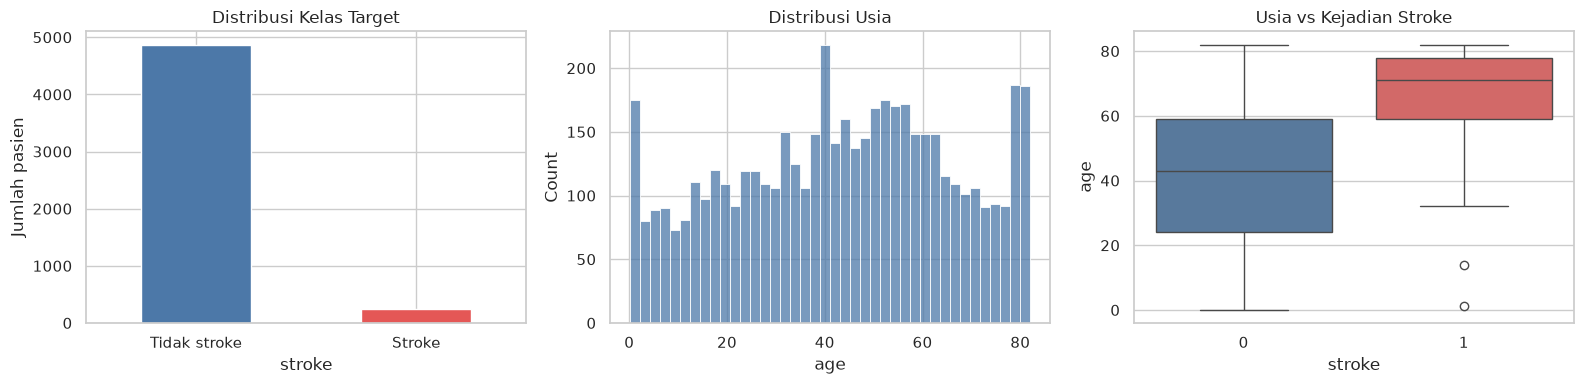

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ringkas.jumlah.plot(kind="bar", ax=ax[0], color=["#4C78A8", "#E45756"])
ax[0].set_title("Distribusi Kelas Target")
ax[0].set_ylabel("Jumlah pasien")
ax[0].tick_params(axis="x", rotation=0)

sns.histplot(df.age, bins=40, ax=ax[1], color="#4C78A8")
ax[1].set_title("Distribusi Usia")

sns.boxplot(data=df, x="stroke", y="age", ax=ax[2], palette=["#4C78A8", "#E45756"])
ax[2].set_title("Usia vs Kejadian Stroke")

plt.tight_layout()
plt.show()

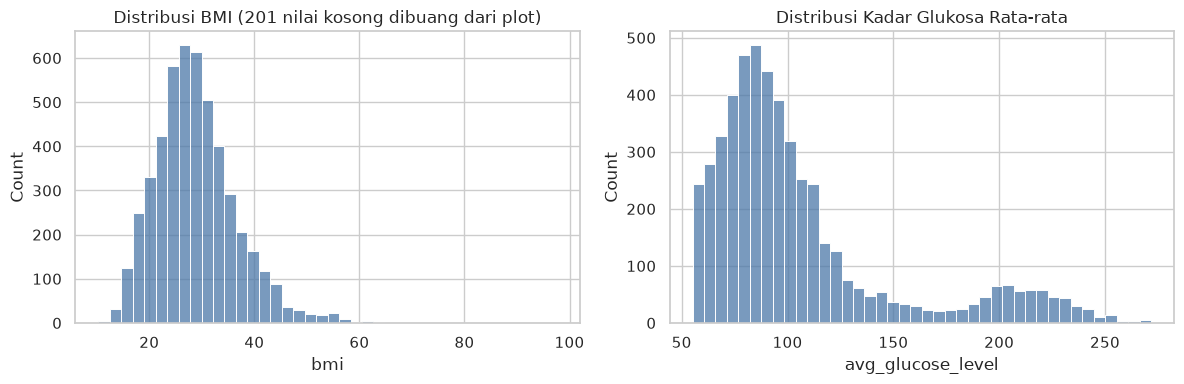

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df.bmi.dropna(), bins=40, ax=ax[0], color="#4C78A8")
ax[0].set_title("Distribusi BMI (201 nilai kosong dibuang dari plot)")

sns.histplot(df.avg_glucose_level, bins=40, ax=ax[1], color="#4C78A8")
ax[1].set_title("Distribusi Kadar Glukosa Rata-rata")

plt.tight_layout()
plt.show()

## 7. Pemeriksaan Outlier dan Nilai Tidak Masuk Akal

Nilai ekstrem belum tentu salah — bisa jadi memang ada pasien seperti itu. Yang penting
adalah memeriksanya, bukan langsung membuangnya.

In [12]:
print("Rentang BMI      :", df.bmi.min(), "-", df.bmi.max())
print("Rentang usia     :", df.age.min(), "-", df.age.max())
print("Rentang glukosa  :", df.avg_glucose_level.min(), "-", df.avg_glucose_level.max())
print()

# BMI di atas 60 sangat jarang secara medis
print("Pasien dengan BMI > 60:", (df.bmi > 60).sum())
display(df[df.bmi > 60][["age", "bmi", "avg_glucose_level", "stroke"]])

# Usia balita — apakah wajar ada di dataset stroke?
print("\nPasien berusia di bawah 2 tahun:", (df.age < 2).sum())

Rentang BMI      : 10.3 - 97.6
Rentang usia     : 0.08 - 82.0
Rentang glukosa  : 55.12 - 271.74

Pasien dengan BMI > 60: 13


,age,bmi,avg_glucose_level,stroke
270,57.0,60.9,129.54,0
358,52.0,64.8,78.40,0
466,61.0,60.2,170.05,0
544,42.0,71.9,210.48,0
928,23.0,78.0,70.03,0
1559,53.0,66.8,72.63,0
2128,17.0,97.6,61.67,0
2764,24.0,63.3,85.55,0
2840,52.0,61.2,98.27,0
3825,52.0,61.6,118.46,0



Pasien berusia di bawah 2 tahun: 120


## 8. Bukti Awal: Mengapa Akurasi Menyesatkan

Percobaan kecil untuk membuktikan pernyataan di bagian 5. Ini belum pemodelan
sesungguhnya — hanya demonstrasi bahwa metrik yang salah menghasilkan kesimpulan
yang salah.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

d = df.drop(columns=["id"])
d["bmi"] = d.bmi.fillna(d.bmi.median())          # imputasi sementara, dibahas serius nanti
X = pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True)
y = d.stroke

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

hasil = []

# Baseline: selalu menebak "tidak stroke"
tebakan_polos = np.zeros(len(y_test))
hasil.append(["Selalu tebak tidak stroke",
              accuracy_score(y_test, tebakan_polos),
              recall_score(y_test, tebakan_polos, zero_division=0),
              precision_score(y_test, tebakan_polos, zero_division=0)])

for nama, opsi in [("Logistic Regression apa adanya", {}),
                   ("Logistic Regression + class_weight", {"class_weight": "balanced"})]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, **opsi))
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    hasil.append([nama,
                  accuracy_score(y_test, pred),
                  recall_score(y_test, pred, zero_division=0),
                  precision_score(y_test, pred, zero_division=0)])
    print(f"{nama} — confusion matrix:")
    print(confusion_matrix(y_test, pred), "\n")

pd.DataFrame(hasil, columns=["Model", "Akurasi", "Recall", "Precision"]).round(3)

Logistic Regression apa adanya — confusion matrix:
[[972   0]
 [ 49   1]] 

Logistic Regression + class_weight — confusion matrix:
[[722 250]
 [ 10  40]] 



,Model,Akurasi,Recall,Precision
0,Selalu tebak tidak stroke,0.951,0.00,0.000
1,Logistic Regression apa adanya,0.952,0.02,1.000
2,Logistic Regression + class_weight,0.746,0.80,0.138


## 9. Ringkasan Temuan

| Aspek | Hasil |
|---|---|
| Jumlah data | 5.110 baris × 12 kolom |
| Missing value eksplisit | `bmi` — 201 baris (3,93%) |
| Missing value tersembunyi | `smoking_status` = "Unknown" — 1.544 baris (30,2%) |
| Duplikat baris | Tidak ada |
| Kategori janggal | `gender` = "Other" hanya 1 baris |
| Outlier | BMI maksimum 97,6 — perlu diperiksa |
| Ketidakseimbangan kelas | 249 stroke : 4.861 tidak stroke (**19,5 : 1**) |

**Kesimpulan sementara:** data layak dipakai, tetapi butuh penanganan pada tiga hal —
imputasi `bmi`, perlakuan terhadap `smoking_status` "Unknown", dan penanganan
ketidakseimbangan kelas.

**Rencana tahap berikutnya:**
1. Imputasi `bmi` — bandingkan hapus baris vs isi median vs isi median per kelompok usia
2. `smoking_status` "Unknown" — diperlakukan sebagai kategori tersendiri, bukan dibuang
   (30% data terlalu besar untuk dihapus)
3. Encoding variabel kategorikal
4. Perbandingan penanganan ketidakseimbangan: tanpa penanganan vs `class_weight` vs SMOTE
5. Perbandingan algoritma: Logistic Regression, KNN, Decision Tree, Random Forest, SVM
6. Interpretasi model dengan SHAP (Explainable AI)
